### Load dataset and construct the L-ensemble

In [113]:
import datetime

import pandas as pd
import numpy as np

from utils import get_age_in_days, construct_L_Ensemble

df = pd.read_csv('tournesol_scores_above_20_2024-03-27.csv')

#Test parameters
bundle_size = 4
power = 2.8 #Model parameters
discount = 7.3
caracteristic_time = 31

recent_videos_proportion = 0.75
recent_videos_to_sample = int(bundle_size * recent_videos_proportion)
old_videos_to_sample = int(bundle_size * (1 - recent_videos_proportion))
                           
#Computes the age of each video
today = datetime.datetime.today()
df['age_in_days'] = df.apply(lambda x: get_age_in_days(x, today), axis="columns")

dpp = construct_L_Ensemble(df, power, discount, caracteristic_time)

L_dual = Phi Phi.T was computed: Phi (dxN) with d<N


### Measures the number of different channels per bundle

<AxesSubplot:ylabel='Count'>

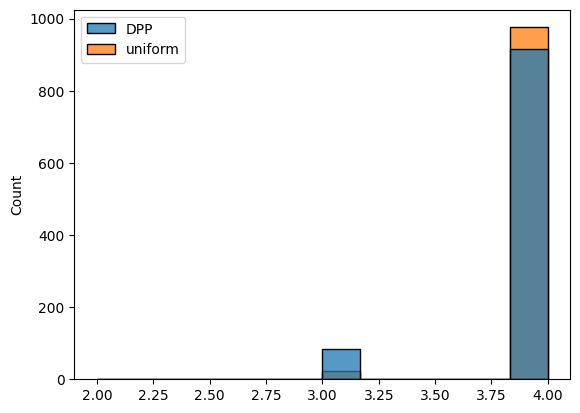

In [118]:
import seaborn as sns

n_tests = 1000

n_channel = pd.DataFrame(columns = ['DPP', 'uniform'])

#dpp sampling
n_channel['DPP'] = pd.Series(
    [len(df.loc[
        df.index[dpp.sample_exact_k_dpp(size=bundle_size)],
        'channel'
        ].unique()
    ) 
    for i in range(n_tests)],
    name="DPP"
)

# Uniform sampling
n_channel['uniform'] = pd.Series(
    data=[len(
        pd.concat([
            df.loc[df["age_in_days"] <= 21]
                .sample(
                    n=recent_videos_to_sample, 
                    replace=False
            ), 
            df.loc[df["age_in_days"] > 21]
                .sample(
                    n=old_videos_to_sample, 
                    replace=False
            )
        ])['channel']
            .unique()
    )
    for i in range(n_tests)
    ],
    name="uniform"
)
   
sns.histplot(n_channel)

### View count, age and duration distributions

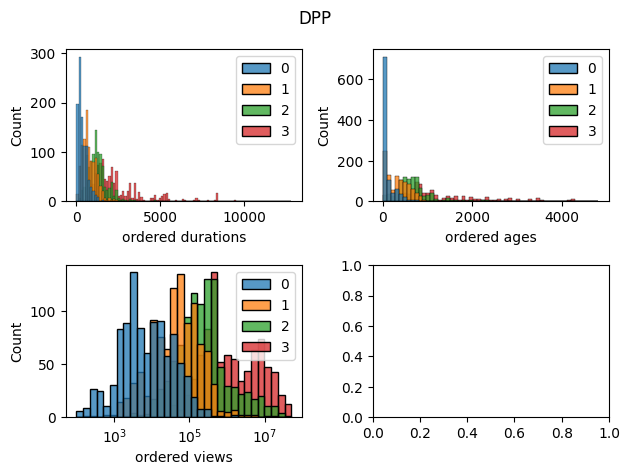

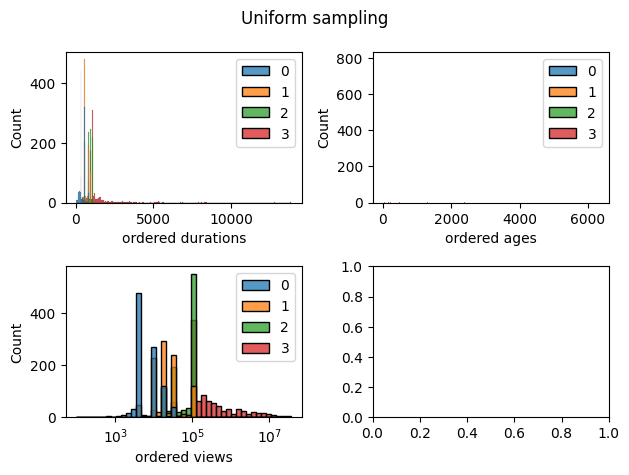

In [211]:
import seaborn as sns

from utils import duration_in_secs

n_tests = 1000

#DPP
bundles_indexes = [
    dpp.sample_exact_k_dpp(size=bundle_size)
    for i in range(n_tests)
]

f, axs = plt.subplots(2, 2)

durations = df['duration'].apply(duration_in_secs)
ordered_duration = pd.DataFrame(
    data=[durations.loc[bundle_indexes]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[0,0].set_xlabel('ordered durations')
sns.histplot(data=ordered_duration, ax=axs[0,0])

ordered_age = pd.DataFrame(
    data=[df['age_in_days'].loc[bundle_indexes]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[0,1].set_xlabel('ordered ages')
sns.histplot(data=ordered_age, ax=axs[0, 1])

ordered_view_count = pd.DataFrame(
    data=[df['view_count'].loc[bundle_indexes]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[1,0].set_xlabel('ordered views')
axs[1,0].set_xscale('log')
sns.histplot(data=ordered_view_count, ax=axs[1, 0])

f.suptitle('DPP')
f.tight_layout()

#Uniform
bundles_indexes = [
    list(
        df.loc[df["age_in_days"] <= 21].sample(
            n=recent_videos_to_sample, 
            replace=False
        ).index
    )+
    list(
        df.loc[df["age_in_days"] > 21].sample(
            n=old_videos_to_sample, 
            replace=False
        ).index
    )
    for i in range(n_tests)
]

f, axs = plt.subplots(2, 2)

ordered_duration = pd.DataFrame(
    data=[durations.loc[bundle_indexes]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[0,0].set_xlabel('ordered durations')
sns.histplot(data=ordered_duration, ax=axs[0,0])

ordered_age = pd.DataFrame(
    data=[df['age_in_days'].loc[bundle_indexes]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[0,1].set_xlabel('ordered ages')
sns.histplot(data=ordered_age, ax=axs[0, 1])

ordered_view_count = pd.DataFrame(
    data=[df['view_count'].loc[bundle_indexes]
        .sort_values()
        .to_list()     
    for bundle_indexes in bundles_indexes],
)
axs[1,0].set_xlabel('ordered views')
axs[1,0].set_xscale('log')
sns.histplot(data=ordered_view_count, ax=axs[1, 0])

f.suptitle('Uniform sampling')
f.tight_layout()

### Criteria maximums

In [ ]:
from utils import CRITERIA

n_tests = 1000

dpp_indexes = [
    dpp.sample_exact_k_dpp(size=bundle_size)
    for i in range(n_tests)
]

uniform_indexes = [
    list(
        df.loc[df["age_in_days"] <= 21].sample(
            n=recent_videos_to_sample, 
            replace=False
        ).index
    )+
    list(
        df.loc[df["age_in_days"] > 21].sample(
            n=old_videos_to_sample, 
            replace=False
        ).index
    )
    for i in range(n_tests)
]

f, axs = plt.subplots(2, 5)

maxs = df[CRITERIA].max()
mins = df[CRITERIA].min()

criteria_maximums = pd.DataFrame(
    columns = CRITERIA + ['sampling'],
    data = [
        list(
           (df.loc[df.index[bundle_indexes], CRITERIA].max()-mins)
                /(maxs-mins)
        )+['dpp']
        for bundle_indexes in dpp_indexes] + 
        [
        list(
           (df.loc[df.index[bundle_indexes], CRITERIA].max()-mins)
                /(maxs-mins)
        )+['uniform']
        for bundle_indexes in uniform_indexes]
)

for i in range(len(CRITERIA)):
    legend = False
    if i == 0:
        legend = True
    sns.histplot(data=criteria_maximums,
                x=CRITERIA[i], 
                hue='sampling',
                legend=legend,
                ax=axs[i % 2, i % 5]
    )
   

f.tight_layout()

In [215]:
criteria_maximums

,largely_recommended,reliability,importance,engaging,pedagogy,layman_friendly,entertaining_relaxing,better_habits,diversity_inclusion,backfire_risk,sampling
0,0.703723,0.828466,0.791318,0.840974,0.930976,0.880976,0.859850,0.801045,0.571977,0.834173,dpp
1,0.581991,0.809057,0.701471,0.762815,0.876163,0.723376,0.758770,0.738955,0.607582,0.824820,dpp
2,0.833905,0.859889,0.861696,0.857046,0.903400,0.837620,0.483957,0.852687,0.579022,0.835072,dpp
3,0.709533,0.849908,0.799683,0.848249,0.924378,0.725025,0.665170,0.690896,0.550717,0.848022,dpp
4,0.906786,0.828466,0.835449,0.775165,0.941127,0.878668,0.855029,0.793284,0.571209,0.807554,dpp
5,0.739636,0.838817,0.827517,0.840974,0.932499,0.871744,0.695594,0.828806,0.560067,0.837050,dpp
6,0.665698,0.803697,0.743294,0.780071,0.923194,0.880976,0.792851,0.799701,0.607582,0.852338,dpp
7,0.885397,0.843993,0.819008,0.846388,0.933683,0.869271,0.722527,0.792985,0.573770,0.839209,dpp
8,0.584896,0.700739,0.681136,0.598883,0.816951,0.777118,0.590856,0.688507,0.568776,0.811151,dpp
9,0.706892,0.829575,0.788722,0.780748,0.875317,0.809430,0.657523,0.702985,0.568391,0.822842,dpp
